# Market regimes with a from-scratch hidden Markov model

Equity index returns are not one distribution. Long stretches of quiet drift are
punctuated by episodes where volatility triples and the drift turns negative — and a
model that admits this (two states, each Gaussian, with Markov switching) describes
index returns far better than any single-distribution story. This notebook fits a
**2-state Gaussian HMM implemented from scratch** (Baum-Welch EM with scaled
forward-backward recursions, Viterbi decoding — `src/regimes/hmm.py`, ~200 lines,
tested by recovering known parameters from simulated chains) to 33 years of SPY
returns, and then asks the question that actually matters for using such a model:
**what may a trading rule legitimately know, and when?**

The centrepiece is the *lookahead ladder*. The same regime-scaled allocation is
evaluated three ways — fully causal (parameters refit annually on past data only,
filtered probabilities), with parameter lookahead (full-sample parameters, filtered
probabilities), and with full lookahead (smoothed probabilities) — against
buy-and-hold. Verdict up front: the honest version earns a Sharpe of ~0.78 versus
buy-and-hold's 0.67 with a third of the drawdown (−17% vs −55%), giving up ~4 points
of annual return for that safety; the smoothed-probability fantasy reports Sharpe
~1.74, more than double the honest number; and — the nuance worth remembering —
parameter lookahead turns out to be nearly free while probability lookahead is
everything.

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from regimes import GaussianHMM
from regimes.allocation import evaluate, exposure_from_prob, summarize
from regimes.data import load_prices

ASSETS = Path("..") / "assets"
ASSETS.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 110

spy = load_prices("SPY", cache_dir="../data")
returns = spy.pct_change().dropna()
x = returns.to_numpy()
print(f"SPY daily returns: {returns.index[0].date()} to {returns.index[-1].date()}"
      f"  ({len(returns):,} observations)")

SPY daily returns: 1993-02-02 to 2026-07-02  (8,411 observations)


## 1. The fitted model

Fit by Baum-Welch on the full sample (this full-sample fit is used for *description*
here; the trading section below refits causally). State 0 is relabelled to be the
lower-vol state by convention — mixtures are only identified up to permutation.

In [2]:
model = GaussianHMM.fit(x)
ann = np.sqrt(252)

table = pd.DataFrame({
    "ann mean": model.means * 252,
    "ann vol": model.stds * ann,
    "stay prob": np.diag(model.transition),
    "expected duration (days)": model.expected_duration_days(),
    "stationary share": model.stationary_distribution(),
}, index=["calm", "turbulent"])
table.round(3)

,ann mean,ann vol,stay prob,expected duration (days),stationary share
calm,0.240,0.108,0.986,72.977,0.69
turbulent,-0.148,0.292,0.970,32.839,0.31


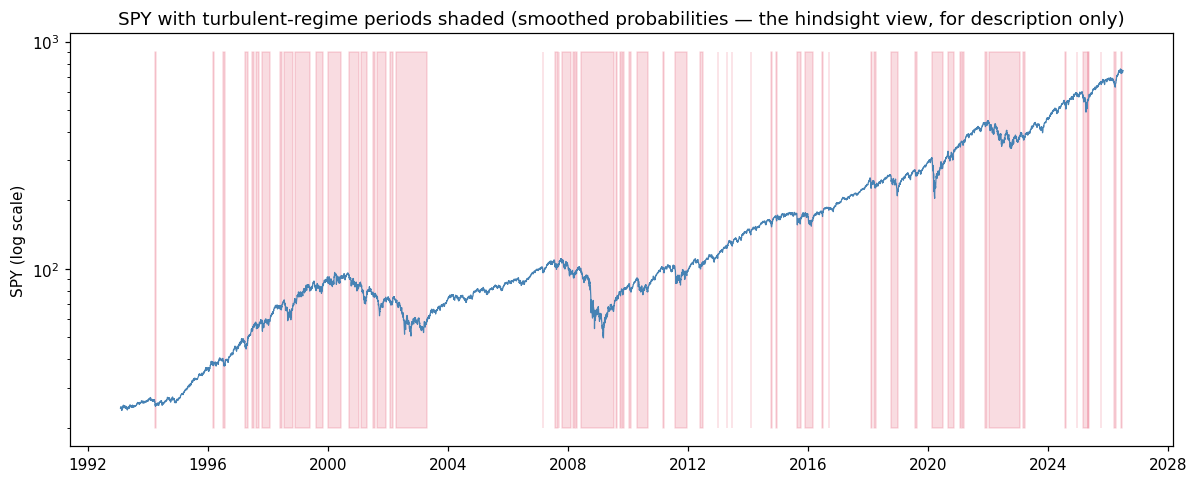

turbulent share of days (smoothed > 0.5): 30%


In [3]:
smoothed = model.smoothed_probabilities(x)[:, 1]  # P(turbulent | all data)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.semilogy(spy.loc[returns.index], lw=0.8, color="steelblue")
in_turbulent = smoothed > 0.5
ax.fill_between(returns.index, *ax.get_ylim(), where=in_turbulent,
                color="crimson", alpha=0.15)
ax.set_title("SPY with turbulent-regime periods shaded "
             "(smoothed probabilities — the hindsight view, for description only)")
ax.set_ylabel("SPY (log scale)")
fig.tight_layout()
fig.savefig(ASSETS / "regimes_shaded.png", bbox_inches="tight")
plt.show()

print(f"turbulent share of days (smoothed > 0.5): {in_turbulent.mean():.0%}")

The model finds exactly the structure practitioners describe qualitatively: a calm
state (vol ≈ 11%, strong positive drift) that hosts about 70% of days and persists
for months, and a turbulent state (vol ≈ 29%, negative drift) that arrives in
clusters — 2000–03, 2008–09, the 2020 crash, 2022 — and persists for weeks. Note the
regime *means* are estimated far less reliably than the vols (a familiar fact:
volatility is easy to estimate, expected returns are not); the allocation below
survives because it keys off the vol separation.

## 2. Filtered vs smoothed — the distinction the whole repo exists for

Filtered probabilities answer "given everything observed *up to today*, which regime
are we in?" — computable in real time. Smoothed probabilities answer "given the whole
history *including the future*, which regime was that day in?" — the right tool for
historical description, and pure lookahead if traded. Around a crisis the difference
is stark: smoothing knows the storm is coming before the first thunderclap.

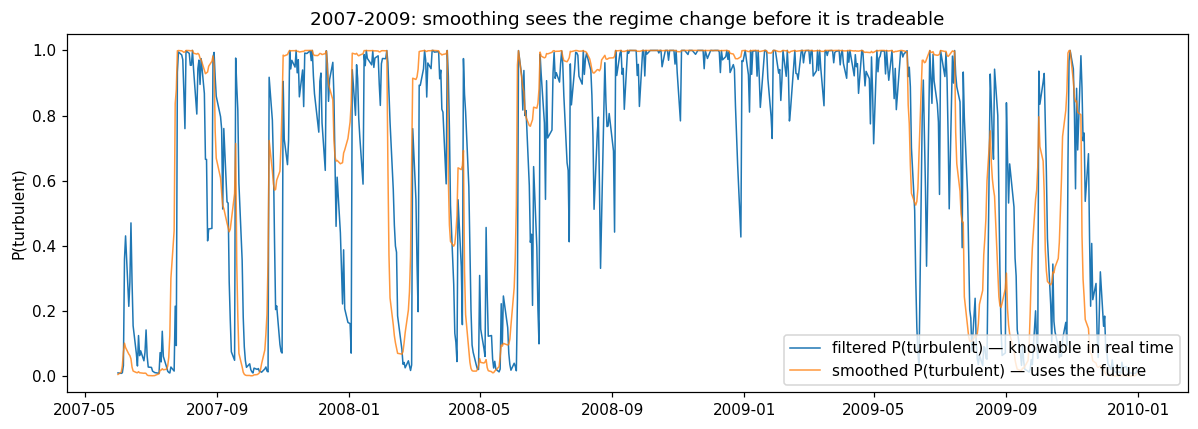

In [4]:
filtered = model.filtered_probabilities(x)[:, 1]
window = slice("2007-06", "2009-12")
filt_series = pd.Series(filtered, index=returns.index).loc[window]
smooth_series = pd.Series(smoothed, index=returns.index).loc[window]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(filt_series, label="filtered P(turbulent) — knowable in real time", lw=1)
ax.plot(smooth_series, label="smoothed P(turbulent) — uses the future", lw=1, alpha=0.8)
ax.set_title("2007-2009: smoothing sees the regime change before it is tradeable")
ax.set_ylabel("P(turbulent)")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(ASSETS / "filtered_vs_smoothed.png", bbox_inches="tight")
plt.show()

Two structural facts, both enforced by the test suite: filtered probabilities satisfy
the *prefix property* (appending future data never changes past values — the same
causality contract as the signals in honest-backtester), and smoothed probabilities
provably do not.

## 3. A regime-aware allocation, evaluated honestly

The rule is deliberately minimal — hold exposure equal to the filtered probability of
the calm state — so that whatever shows up is attributable to the regime model, not
to rule engineering. Honest evaluation means three things at once:

1. **Causal parameters**: refit the HMM each January on data through the prior
   year-end only (first fit uses 1993–2002; evaluation runs 2003–2026).
2. **Causal probabilities**: filtered, never smoothed.
3. **Honest execution**: positions lagged one bar, 2 bps on turnover — the same
   contract as honest-backtester, enforced in `allocation.evaluate`.

In [5]:
close = spy.loc[returns.index]
years = sorted(set(returns.index.year))

causal_pieces = []
for year in [y for y in years if y >= 2003]:
    past = returns[returns.index.year < year]
    through_year = returns[returns.index.year <= year]
    causal_model = GaussianHMM.fit(past.to_numpy())
    probs = causal_model.filtered_probabilities(through_year.to_numpy())[:, 0]
    mask = through_year.index.year == year
    causal_pieces.append(pd.Series(probs[mask], index=through_year.index[mask]))
causal_prob_calm = pd.concat(causal_pieces)

eval_index = causal_prob_calm.index
close_eval = close.loc[eval_index]

strategies = {
    "causal (honest)": exposure_from_prob(causal_prob_calm),
    "param lookahead": exposure_from_prob(
        pd.Series(model.filtered_probabilities(x)[:, 0], index=returns.index).loc[eval_index]),
    "smoothed (full lookahead)": exposure_from_prob(
        pd.Series(model.smoothed_probabilities(x)[:, 0], index=returns.index).loc[eval_index]),
    "buy & hold": pd.Series(1.0, index=eval_index),
}

results = {}
for name, positions in strategies.items():
    cost = 0.0 if name == "buy & hold" else 2.0
    results[name] = evaluate(close_eval, positions, cost_bps=cost)

summary = pd.DataFrame({name: summarize(res.net_return)
                        for name, res in results.items()}).T
summary.round(3)

,annual_return,annual_vol,sharpe,max_drawdown
causal (honest),0.071,0.093,0.783,-0.169
param lookahead,0.073,0.097,0.769,-0.231
smoothed (full lookahead),0.162,0.089,1.736,-0.097
buy & hold,0.114,0.186,0.674,-0.552


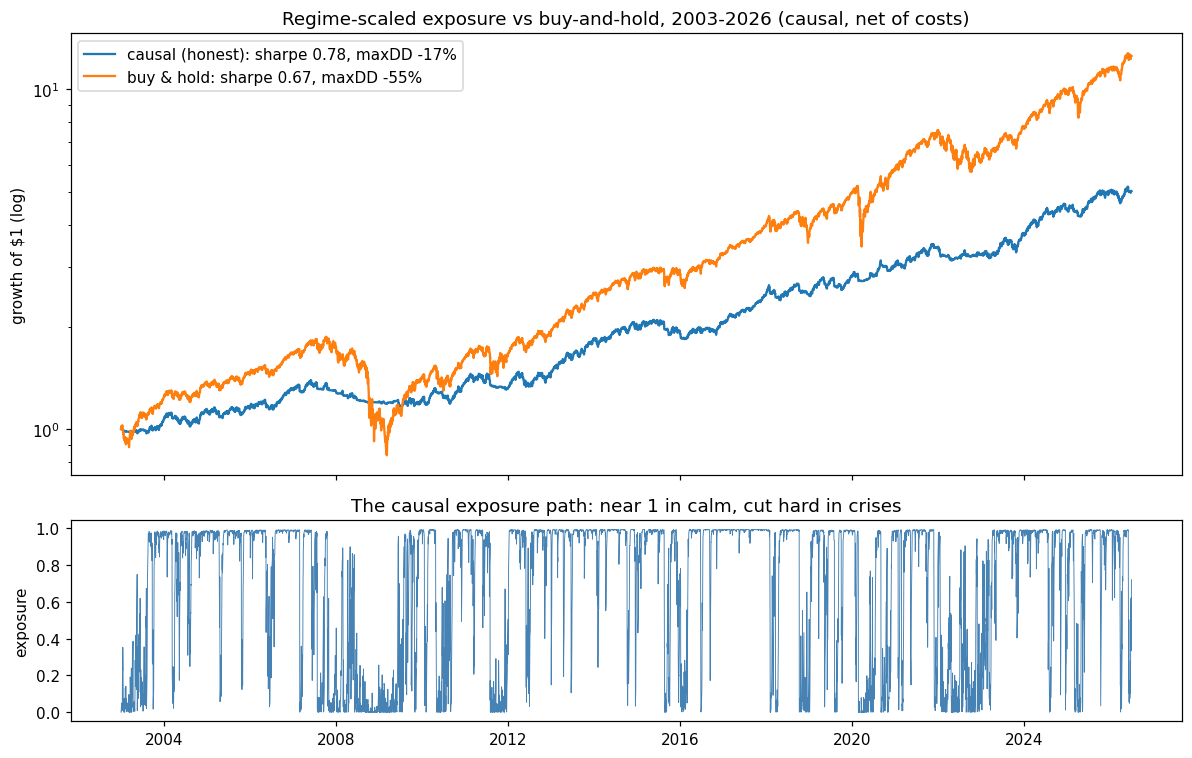

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               height_ratios=[2.2, 1])
for name in ["causal (honest)", "buy & hold"]:
    equity = (1 + results[name].net_return).cumprod()
    stats = summarize(results[name].net_return)
    ax1.plot(equity, label=f"{name}: sharpe {stats['sharpe']:.2f}, "
                           f"maxDD {stats['max_drawdown']:.0%}")
ax1.set_yscale("log")
ax1.set_ylabel("growth of $1 (log)")
ax1.set_title("Regime-scaled exposure vs buy-and-hold, 2003-2026 (causal, net of costs)")
ax1.legend()

ax2.plot(results["causal (honest)"].held, lw=0.6, color="steelblue")
ax2.set_ylabel("exposure")
ax2.set_title("The causal exposure path: near 1 in calm, cut hard in crises")
fig.tight_layout()
fig.savefig(ASSETS / "regime_equity.png", bbox_inches="tight")
plt.show()

The honest read of that table: regime-scaling is a **risk transformer, not a return
machine**. It gives up about four points of annual return and in exchange halves the
volatility and cuts the worst drawdown from −55% to −17%, which nets out to a Sharpe
of ~0.78 vs 0.67. Whether that trade is attractive depends on the investor's
constraint (leverage-constrained investors should love it; return maximisers should
not) — a modest, defensible claim, and the plot of the exposure path shows the
mechanism: near-full exposure through calm years, cut hard and early in 2008, 2020,
and 2022.

## 4. The lookahead ladder — where cheating actually hides

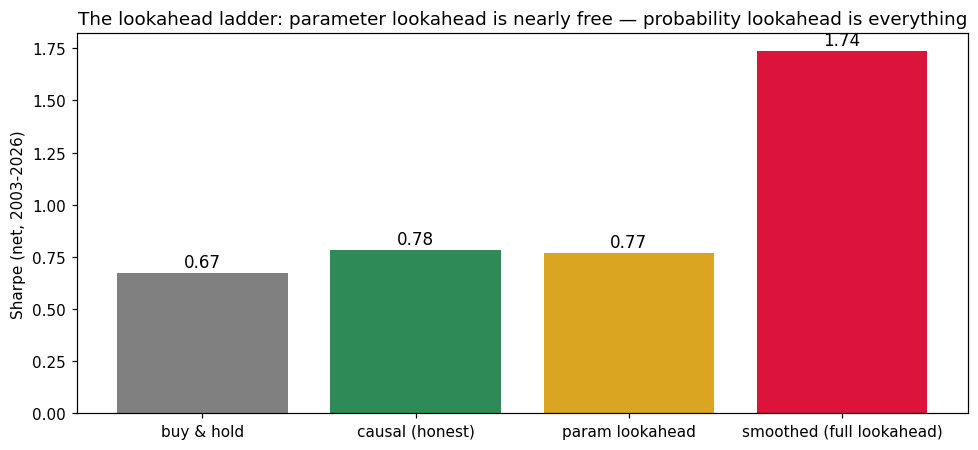

In [7]:
order = ["buy & hold", "causal (honest)", "param lookahead", "smoothed (full lookahead)"]
sharpes = [summarize(results[name].net_return)["sharpe"] for name in order]

fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.bar(order, sharpes,
              color=["gray", "seagreen", "goldenrod", "crimson"])
for bar, s in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width() / 2, s + 0.03, f"{s:.2f}",
            ha="center", fontsize=11)
ax.set_ylabel("Sharpe (net, 2003-2026)")
ax.set_title("The lookahead ladder: parameter lookahead is nearly free — "
             "probability lookahead is everything")
fig.tight_layout()
fig.savefig(ASSETS / "lookahead_ladder.png", bbox_inches="tight")
plt.show()

This is the finding to remember. **Parameter lookahead barely matters** (0.77 vs
0.78): regime *parameters* are stable enough that fitting them on the future adds
almost nothing — which also says the annual-refit discipline, while correct, was not
where the danger lived. **Probability lookahead more than doubles the Sharpe**
(1.74 vs 0.78) and shrinks the max drawdown to −10%: smoothing exits before crashes
because it has read tomorrow's newspaper. A backtest of an HMM strategy that quotes
smoothed (or Viterbi-decoded) states — and many do, because those are the arrays the
libraries hand back first — is reporting the crimson bar while believing it earned
the green one.

## 5. Verdict and limitations

1. A from-scratch 2-state Gaussian HMM, validated by parameter recovery on simulated
   chains, finds the canonical calm/turbulent structure in SPY: 11% vs 29% vol,
   +24% vs −15% drift, months-long calm spells, weeks-long storms.
2. Traded honestly (causal parameters, filtered probabilities, lagged execution,
   costs), regime-scaling is a risk transformer: Sharpe 0.78 vs 0.67, max drawdown
   −17% vs −55%, at the price of ~4 points of annual return.
3. The lookahead ladder localises the danger: parameters are nearly lookahead-proof,
   probabilities are not — smoothed states inflate Sharpe from 0.78 to 1.74.

**Limitations:** two states is an a-priori choice (a third state often splits
"turbulent" into correction vs crisis); Gaussian emissions understate tails within
regimes; the exposure rule was not tuned (deliberately) but also not compared against
the simpler benchmark it most resembles — plain volatility targeting, which captures
much of the same effect without a latent-state model; execution at 2 bps with annual
refits is realistic for an ETF but ignores taxes on ~15x annual turnover; and one
index over one 23-year evaluation window is a single draw from a small number of
regime cycles.